In [ ]:
from pathlib import Path
# Paths relative to this notebook's location (notebooks/ dir)
PROJECT_ROOT = Path().resolve().parent
DRHARD_ROOT = PROJECT_ROOT.parent / "DRhard"

In [1]:
%load_ext autoreload
%autoreload 2

from time import time
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
import pickle

In [2]:
import sys
sys.path.insert(0, str(DRHARD_ROOT))

In [3]:
import argparse
import subprocess
import sys
sys.path.append("./")
import faiss
import logging
import os
import numpy as np
# import torch
from transformers import RobertaConfig
from tqdm import tqdm
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.sampler import SequentialSampler

from model import RobertaDot
from dataset import (
    TextTokenIdsCache, load_rel, SubsetSeqDataset, SequenceDataset,
    single_get_collate_function
)
from retrieve_utils import (
    construct_flatindex_from_embeddings, 
    index_retrieve, convert_index_to_gpu
)
logger = logging.Logger(__name__)

In [4]:
doc_memmap_path = str(DRHARD_ROOT / "data/passage/evaluate/star/passages.memmap")
docid_memmap_path = str(DRHARD_ROOT / "data/passage/evaluate/star/passages-id.memmap")
query_memmap_path = str(DRHARD_ROOT / "data/passage/evaluate/star/test-manual-query.memmap")
queryids_memmap_path = str(DRHARD_ROOT / "data/passage/evaluate/star/test-manual-query-id.memmap")

# query_adore_memmap_path = str(DRHARD_ROOT / "data/passage/evaluate/adore-star/test-manual.qembed.memmap")

In [5]:
doc_embeddings = np.memmap(doc_memmap_path, dtype=np.float32, mode="r")
doc_ids = np.memmap(docid_memmap_path, dtype=np.int32, mode="r")
doc_embeddings = doc_embeddings.reshape(-1, 768)

query_embeddings = np.memmap(query_memmap_path, dtype=np.float32, mode="r")
query_embeddings = query_embeddings.reshape(-1, 768)
query_ids = np.memmap(queryids_memmap_path, dtype=np.int32, mode="r")

In [6]:
%time
index = construct_flatindex_from_embeddings(doc_embeddings, doc_ids)

CPU times: user 3 µs, sys: 2 µs, total: 5 µs
Wall time: 10.5 µs
embedding shape: (38626614, 768)
(38626614,) int64


In [7]:
type(index)

faiss.swigfaiss.IndexIDMap2

# Select certain queries and certain docs for small index

In [8]:
# Load our qid and docid remapping dictionaries

# query id dict
qid_mapping_path = str(DRHARD_ROOT / "data/passage/dataset/queries.CASTmanual.QID2newID.test.tsv")
queries_df = pd.read_csv(qid_mapping_path, delimiter="\t", header=None)
print(len(queries_df))

# collection id dict
collection_mapping_path = str(DRHARD_ROOT / "data/passage/dataset/CASTcollectionPID2newID.tsv")
collection_df = pd.read_csv(collection_mapping_path, delimiter="\t", header=None)
print(len(collection_df))

479
38626614


In [9]:
qid2newqid_dict = dict(zip(queries_df[0], queries_df[1])) 
pid2newpid_dict = dict(zip(collection_df[0], collection_df[1])) 

In [10]:
qid2newqid_dict["32_1"]

9

In [11]:
# Create reverse dictionaries
newqid2qid_dict = dict(zip(queries_df[1], queries_df[0])) 
newpid2pid_dict = dict(zip(collection_df[1], collection_df[0])) 

In [12]:
newqid2qid_dict[9]

'32_1'

In [13]:
# DRhard docid and qid encoding
preprocess_dir = str(DRHARD_ROOT / "data/passage/preprocess")

pid2offset = pickle.load(open(os.path.join(preprocess_dir, "pid2offset.pickle"), 'rb'))
offset2pid = {v:k for k, v in pid2offset.items()}
qid2offset = pickle.load(open(os.path.join(preprocess_dir, f"test-manual-qid2offset.pickle"), 'rb'))
offset2qid = {v:k for k, v in qid2offset.items()}

In [14]:
qid2offset[9]

9

In [15]:
conv_qrel_int = [31, 32, 33, 34, 37, 40, 49, 50, 54, 56, 58, 59, 61, 67, 68, 69, 75, 77, 78, 79]
conv_qrel = [str(x) for x in conv_qrel_int]
conv_qrel

['31',
 '32',
 '33',
 '34',
 '37',
 '40',
 '49',
 '50',
 '54',
 '56',
 '58',
 '59',
 '61',
 '67',
 '68',
 '69',
 '75',
 '77',
 '78',
 '79']

# Compute all possible distances in cache!!!

In [18]:
all_dist_dict = {}
qa_qb_dist = {}
for convid in conv_qrel:
    print(convid)
    # qa
    first_qid = convid + "_1"
    first_newqid = qid2newqid_dict[first_qid] #added first
    first_qid_offset = qid2offset[first_newqid]
    print(first_qid, first_qid_offset)

    # prendere il memmap
    first_query_emb = query_embeddings[first_qid_offset].reshape(1, 768)
    
    # fare retireval nel indice grande e prendere top 10000 documenti
    faiss.omp_set_num_threads(16) #32
    nearest_neighbors_ra = index_retrieve(index, first_query_emb, 10000, batch=32)
    print(len(nearest_neighbors_ra[0]))

    # compute dist between q_1 and all retrieved docs
    q_p_dist_list = []
    for docid in nearest_neighbors_ra[0]:
        doc_emb = doc_embeddings[docid].reshape(1, 768)
        
        q_p_dist = l2_distance(query_emb, doc_emb)
        q_p_dist_list.append(q_p_dist)
    
    all_dist_dict[first_qid] = q_p_dist_list
    print(len(q_p_dist_list))
    
    ### compute dist between all other q in the same conv and all retrieved docs
    # get conv ids
    conv_qids = [qid for qid in qid2newqid_dict.keys() if qid.startswith(convid+"_") and not qid.endswith("_1")]
    print(conv_qids)
    
    # get qid emb
    for qid in conv_qids:
        newqid = qid2newqid_dict[qid] #added first
        qid_offset = qid2offset[newqid]
        print(qid, qid_offset)
        # the header are the docids, the index the queryids
        query_emb = query_embeddings[qid_offset].reshape(1, 768)
        
        #qa qb dist
        qa_qb_dist[qid] = l2_distance(first_query_emb, query_emb)
        
        # query doc dist
        q_p_dist_list = []
        for docid in nearest_neighbors_ra[0]:
            doc_emb = doc_embeddings[docid].reshape(1, 768)

            q_p_dist = l2_distance(query_emb, doc_emb)
            q_p_dist_list.append(q_p_dist)
        
        all_dist_dict[qid] = q_p_dist_list

In [19]:
#### Saving variables
%store all_dist_dict
%store nearest_neighbors_ra
%store qa_qb_dist

Stored 'all_dist_dict' (dict)
Stored 'nearest_neighbors_ra' (list)
Stored 'qa_qb_dist' (dict)


# Create conv cache

In [23]:
topk = 10000 # cache dimension [1000,2000,5000,10000]
# evaluation is done on top 1000 - another topk?

In [24]:
# distance dicts

cache_radius_dict = dict() # between first utterance (qa) and last retrieved doc from the big index
query_distance_dict = dict() # distance between the first (qa) and the rest of utterances of the conversation (qb)
query_radius_dict = dict() # between current utterance (qb) and last retrieved doc from the big index
diff_distance_dict = dict() # rb_hat = ra - d(qb, qa)

In [25]:
def l2_distance(v1,v2):
    return np.linalg.norm(v1-v2)

In [26]:
def create_conv_cache(conv_id, qid2newqid_dict, qid2offset, query_embeddings, doc_embeddings, 
                      index, topk, cache_radius_dict):
    # first utt of the conversation - determines the size of the cache
    first_qid = conv_id + "_1"
    newqid = qid2newqid_dict[first_qid] #added first
    qid_offset = qid2offset[newqid]

    # prendere il memmap
    query_emb = query_embeddings[qid_offset].reshape(1, 768)
    
    # fare retireval nel indice grande e prendere top 2000 documenti
    faiss.omp_set_num_threads(16) #32
    nearest_neighbors = index_retrieve(index, query_emb, topk, batch=32)
    
    # select doc embeddings, paired with ids
    small_doc_emb = doc_embeddings[nearest_neighbors[0]]
    small_doc_ids = np.array(nearest_neighbors[0])
    index_conv = construct_flatindex_from_embeddings(small_doc_emb, small_doc_ids)
       
    # compute distance between the first query and last doc in the list of topk retrieved that are stored in cache (e.g., r_q_i)
    last_doc = nearest_neighbors[0][-1]
    last_doc_embedding = doc_embeddings[last_doc]
    cache_radius_dict[first_qid] = l2_distance(query_emb, last_doc_embedding)
    
    return index_conv, nearest_neighbors, cache_radius_dict

In [ ]:
# conv_ids = set([x.split("_")[0] for x in qid2newqid_dict.keys()]) # this has all but we don't need all, just the ones in qrel
# conv in qrel: subset of all conv
conv_qrel_int = [31, 32, 33, 34, 37, 40, 49, 50, 54, 56, 58, 59, 61, 67, 68, 69, 75, 77, 78, 79]
conv_qrel = [str(x) for x in conv_qrel_int]


results_list = []  # top1000 rankings for each query of the conversation from the CACHE index
coverage1 = {} # top10 ranking for each query from the BIG index
coverage2 = {} # list of triples (3,5,10) for each qb

for conv_id in conv_qrel: # iterate over the conversations
    
    print("Starting conv: " , conv_id)
    
    # ALL QA
    # Create index for first query and retrieve nearest neighbours - top 2000
    index_conv, nearest_neighbors, cache_radius_dict = create_conv_cache(conv_id, qid2newqid_dict, 
                                                                         qid2offset, query_embeddings, 
                                                                         doc_embeddings, index, topk, 
                                                                         cache_radius_dict)
    print("Create cache for: ", conv_id)
    
    # save docs for qa for coverage
    retrieved_qa = nearest_neighbors[0]
        
    # first  query id & embedding
    first_qid = conv_id + "_1"
    first_newqid = qid2newqid_dict[first_qid] #added first
    first_qid_offset = qid2offset[first_newqid]
    
    # save results - top 1000 for first conv query qa
    for idx, pid in enumerate(nearest_neighbors[0][:1000]):
        results_list.append((first_qid_offset, pid, idx+1))
    
    # prendere il memmap di qa
    first_query_emb = query_embeddings[first_qid_offset].reshape(1, 768)
    
    # for each utt in the rest of the conv: qb
    for qid in qid2newqid_dict.keys():
        if not qid.endswith("_1") and qid.startswith(conv_id):
            print("Processing qid:", qid)
            # select query embedding
            newqid = qid2newqid_dict[qid]
            qid_offset = qid2offset[newqid]
            # prendere il memmap
            query_emb = query_embeddings[qid_offset].reshape(1, 768)
            
            # retrieve docs for qb
            faiss.omp_set_num_threads(16) #32
            nearest_neighbors = index_retrieve(index_conv, query_emb, 1000, batch=32)
            print("Retrieved top 1000 for", qid)
            
            # save results - top1000, for qb
            for idx, pid in enumerate(nearest_neighbors[0]):
                results_list.append((qid_offset, pid, idx+1))
            
            print("Computing distances and coverage!")
            #### Compute DISTANCES rb_hat
            
            # compute distance between qb and qa
            query_distance_dict[qid] = l2_distance(query_emb, first_query_emb)
            
            # compute rb_capuccio = ra - d(qb, qa)
            diff_distance_dict[qid] = cache_radius_dict[first_qid] - query_distance_dict[qid]
            
            #### Compute COVERAGE 
            # Cov1 - intersezione tra Ba ed Bb_hat
            # distance between qb and each doc in top1000 from cache and check if < rb_hat
            # put them in a list - exact match - and intersect with top k in cache
            retrieved_qb_in_rb_hat = []
            small_doc_emb = doc_embeddings[nearest_neighbors[0]]
            for doc_id, doc_emb in zip(nearest_neighbors[0], small_doc_emb):
                if l2_distance(query_emb, doc_emb) < diff_distance_dict[qid]:
                    retrieved_qb_in_rb_hat.append(doc_id)
            coverage1[qid]=len(retrieved_qb_in_rb_hat)
            print("Finished for Rb hat!")
            
            #### Compute DISTANCES rb
            
            #compute distance between qb and the last retrieved doc from INDEX
            first_10_docs = index_retrieve(index, query_emb, 10, batch=32)
            # 3 raggi rb per 3,5,10
            rb_dist_list = []
            for i in [3,5,10]:
                last_doc_embedding = doc_embeddings[first_10_docs[0][i-1]]
                dist_rb = l2_distance(query_emb, last_doc_embedding)
                rb_dist_list.append(dist_rb)
            query_radius_dict[qid] = rb_dist_list
            print("Finished retrieving in the big index!")
            
            # save top10 for qb in INDEX
            results_list_rb= first_10_docs[0][:10]
            result_list_qb_in_cache = nearest_neighbors[0][:10]
        
            #### Compute COVERAGE          
            # Cov2 - intersezione tra risultati di query qb top 1000 su cache e query qb su indice per k=3,5,10
            num_intersection = []
            for cut_off in [3,5,10]:
                elem_in_common = set(results_list_rb[:cut_off]).intersection(result_list_qb_in_cache[:cut_off])
                num_intersection.append(len(elem_in_common))
            coverage2[qid] = num_intersection
            
            print("finished with qid: ", qid)

In [ ]:
len(results_list)

In [ ]:
# convert ids to original
with open(str(PROJECT_ROOT / "data/star-ranking/CAST-manual-queries-star-L2-ranking-top1000-cache-top")+str(topk)+"-first-utt.bak.tsv", 'w') as outputfile:
    for (qid, pid, idx) in results_list:
        
        new_qid = offset2qid[qid]
        orig_qid = newqid2qid_dict[new_qid]
        
        new_pid = offset2pid[pid]
        orig_pid = newpid2pid_dict[new_pid]
        
        outputfile.write(f"{orig_qid}\t{orig_pid}\t{idx}\n")

# Eval results

In [ ]:
qrel_path = "../data/CAST_qrels/qrels-docs.2019.txt"
qrels_df = pd.read_csv(qrel_path, delimiter=" ", header=None)
qrels_df[[3]] = qrels_df[[3]].astype(int)
qrels_df = qrels_df.drop([1], axis=1)
qrels_df.columns=["qid", "docno", "label"]
qrels = qrels_df

In [ ]:
topics_path='../data/CAST-2019/test_manual_utterance.tsv' #manual

topics_df = pd.read_csv(topics_path, delimiter="\t", header=None)
topics_df.columns=["qid", "query"]
topics = topics_df
topics.head()

In [ ]:
results_path = "../data/star-ranking/CAST-manual-queries-star-L2-ranking-top1000-cache-top"+str(topk)+"-first-utt.bak.tsv"
results_df = pd.read_csv(results_path, delimiter="\t", header=None)
results_df[3] = 1000-results_df[2]
results_df.columns=["qid", "docno", "rank", "score"]
results_df.head()
# Results produced by the transformers must have “qid”, “docno”, “score”, “rank” columns.

In [ ]:
%%time
pt.Experiment([results_df], topics, qrels, names=["STAR"], 
              eval_metrics=["map", "recip_rank", "recall_200", "P_3", "P_1", "ndcg_cut_3"])

# Explore the dictionaries

## save into .tsv files

In [27]:
cache_radius_dict
%store cache_radius_dict

Stored 'cache_radius_dict' (dict)


In [ ]:
with open('../data/adore-star-ranking/cache-radius-adore-star-L2-ranking-top1000-cache-top'+str(topk)+'.tsv', 'w+') as fout:
    for i in cache_radius_dict:
        fout.write((i)+"\t"+str(cache_radius_dict[i])+"\n")

In [28]:
query_distance_dict
%store query_distance_dict

Stored 'query_distance_dict' (dict)


In [ ]:
with open('../data/adore-star-ranking/query-dist-adore-star-L2-ranking-top1000-cache-top'+str(topk)+'.tsv', 'w+') as fout:
    for i in query_distance_dict:
        fout.write((i)+"\t"+str(query_distance_dict[i])+"\n")

In [29]:
query_radius_dict # in the big index
%store query_radius_dict

Stored 'query_radius_dict' (dict)


In [ ]:
with open('../data/adore-star-ranking/query-radius-adore-star-L2-ranking-top1000-cache-top'+str(topk)+'.tsv', 'w+') as fout:
    for i in query_radius_dict:
        fout.write(str(i)+"\t"+str(query_radius_dict[i])+"\n")

In [44]:
diff_distance_dict

In [ ]:
with open('../data/adore-star-ranking/rbhat-adore-star-L2-ranking-top1000-cache-top'+str(topk)+'.tsv', 'w+') as fout:
    for i in diff_distance_dict:
        fout.write(str(i)+"\t"+str(diff_distance_dict[i])+"\n")

In [40]:
coverage1

In [ ]:
with open('../data/adore-star-ranking/garanteed-coverage-adore-star-L2-ranking-top1000-cache-top'+str(topk)+'_v2.tsv', 'w+') as fout:
    for i in coverage1:
        fout.write(str(i)+"\t"+str(coverage1[i])+"\n")

In [41]:
coverage2 # 3,5,10 between top-k 

In [ ]:
with open('../data/adore-star-ranking/approximated-coverage-adore-star-L2-ranking-top1000-cache-top'+str(topk)+'_v2.tsv', 'w+') as fout:
    for i in coverage2:
        fout.write(str(i)+"\t"+str(coverage2[i])+"\n")

In [45]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
import numpy as np

In [46]:
rng = np.random.RandomState(0)

x = list(diff_distance_dict.values()) # rb_hat
y = [c for (a,b,c) in coverage2.values()] # top-10 di gcov

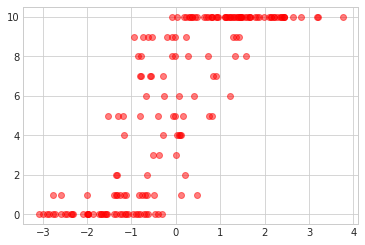

In [47]:
plt.scatter(x, y, c='r', alpha=0.5, cmap='viridis')

In [50]:
print(x)

[1.4491434, -0.023200989, 0.28126335, 0.91070414, 2.3638272, 0.7217188, 0.800241, 1.2422233, 1.3569245, -0.09773302, 0.36956453, 0.025249958, -2.592021, -0.73484755, -0.63732576, -0.8019438, -0.80951405, -0.08105087, 3.2127762, 1.1203008, 1.6663187, 1.8777409, 1.7862699, 1.9945986, 2.1443076, 1.4275537, -2.7631192, 2.2174704, 2.2839406, 1.6457596, 2.431465, 1.435988, 1.5951843, 1.2833138, 2.105629, 3.7660708, 2.442917, 2.4422157, 2.8314629, -0.76299095, -1.2691302, 1.2178807, -0.80968094, -0.72272825, -0.6522231, -0.6273775, 1.1048613, 0.8155594, 0.35423994, -0.02423811, 0.41170502, -0.2821579, -1.3391104, -0.9470701, 0.027021408, 2.15443, -0.25861454, 1.2005744, -0.8633528, -0.06484079, 0.17839956, 1.1126032, 0.120004654, 0.005915642, -0.3194232, 0.73271084, -0.6550927, -3.0039234, -2.589075, -2.8553076, -2.9087267, -2.7606182, -2.7219582, 0.814229, -1.2623558, 0.0657773, 1.1632376, 0.7483201, 0.9071665, -1.9850793, -1.3994379, 2.4030461, 0.46852064, 1.312717, 1.667162, 1.2180438, -1.

In [51]:
print(y)

[10, 9, 8, 7, 10, 10, 10, 10, 10, 10, 10, 4, 1, 9, 9, 7, 5, 9, 10, 10, 10, 10, 10, 10, 10, 9, 0, 10, 10, 10, 10, 10, 10, 9, 10, 10, 10, 10, 10, 1, 1, 6, 0, 0, 1, 0, 10, 5, 10, 5, 6, 7, 0, 9, 10, 10, 6, 10, 8, 5, 10, 10, 4, 3, 0, 8, 2, 0, 0, 0, 0, 1, 0, 10, 0, 4, 10, 5, 10, 0, 1, 10, 10, 10, 10, 10, 0, 10, 10, 10, 9, 10, 8, 1, 1, 5, 0, 1, 0, 0, 0, 10, 10, 10, 7, 1, 0, 0, 0, 4, 10, 10, 3, 7, 0, 1, 5, 0, 0, 0, 8, 10, 0, 5, 5, 0, 0, 10, 9, 7, 10, 0, 0, 1, 0, 5, 1, 4, 6, 10, 10, 9, 3, 6, 8, 10, 9, 8, 2, 10, 4, 0, 0, 0, 2, 2, 7, 10, 10, 10, 10, 10, 0, 1, 0, 1, 1, 8, 0, 0, 0, 0, 0, 0]
